# Sales Prediction Using Machine Learning

## Objective
The objective of this project is to predict product sales based on advertising expenditure on TV, Radio, and Newspaper platforms using Machine Learning models.

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

In [24]:
df = pd.read_csv("../data/advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [26]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [27]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

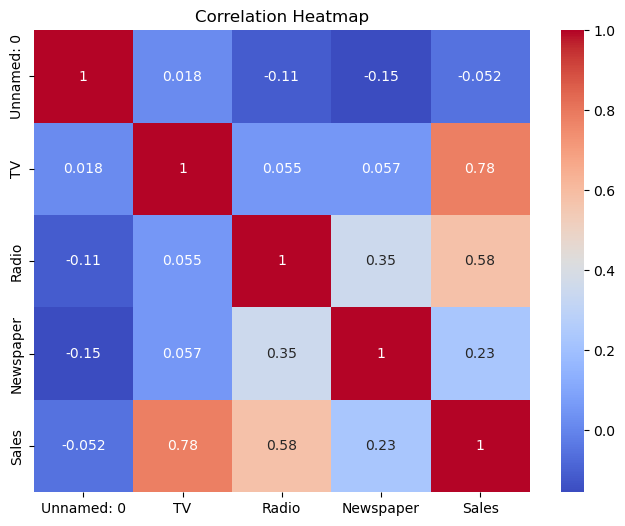

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

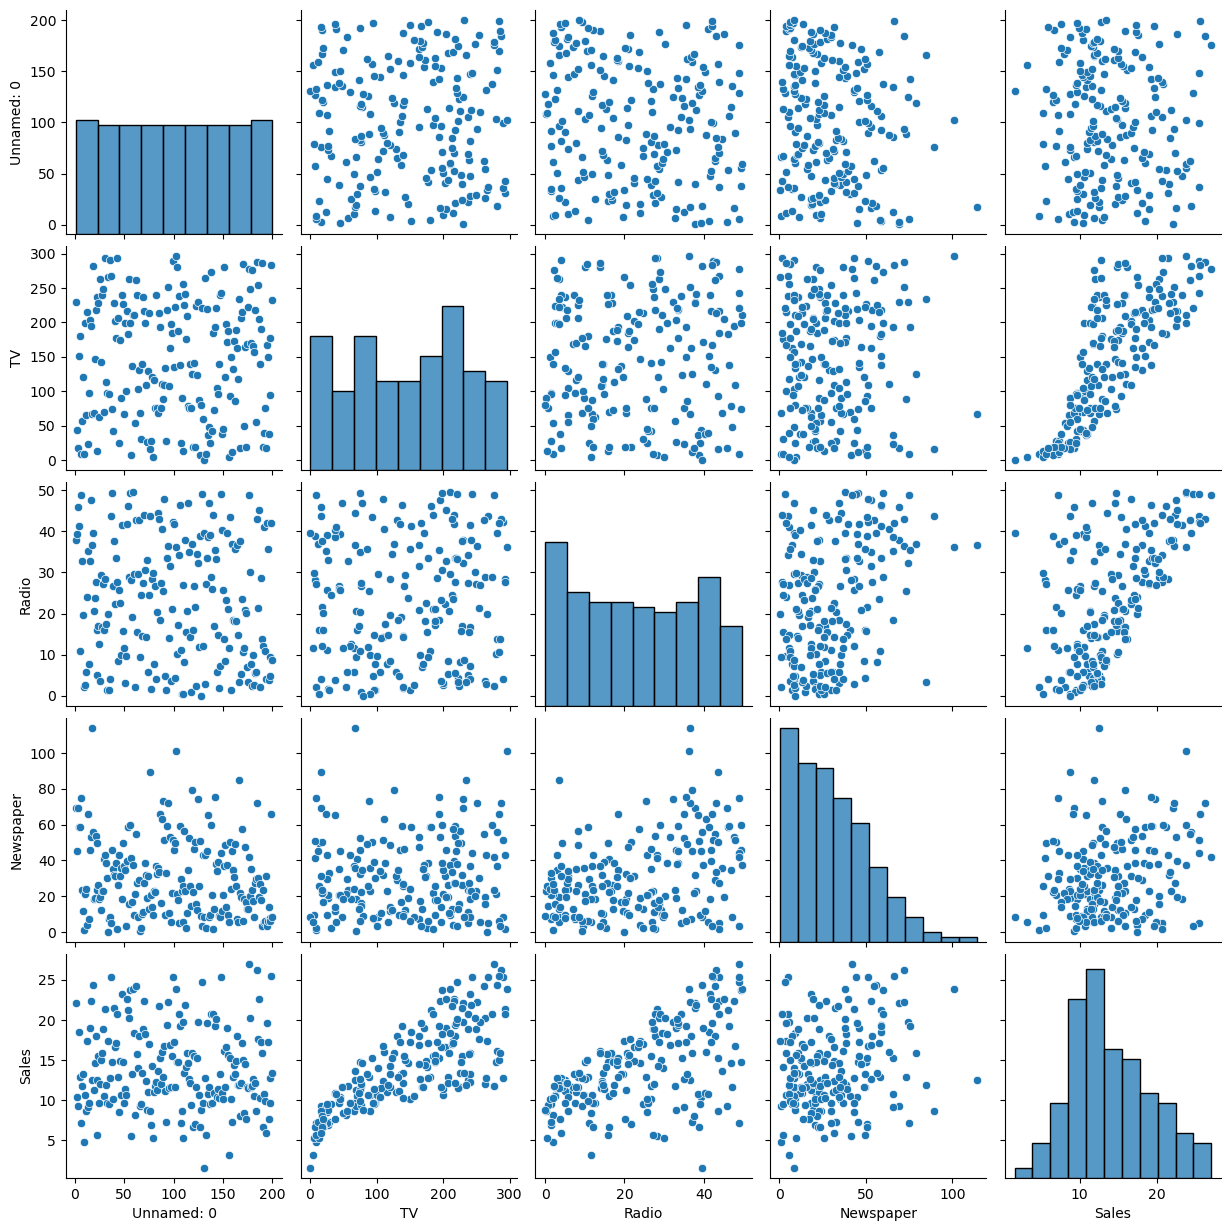

In [29]:
sns.pairplot(df)
plt.show()

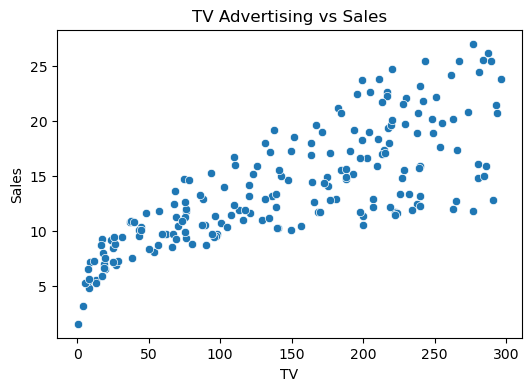

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['TV'], y=df['Sales'])
plt.title("TV Advertising vs Sales")
plt.show()

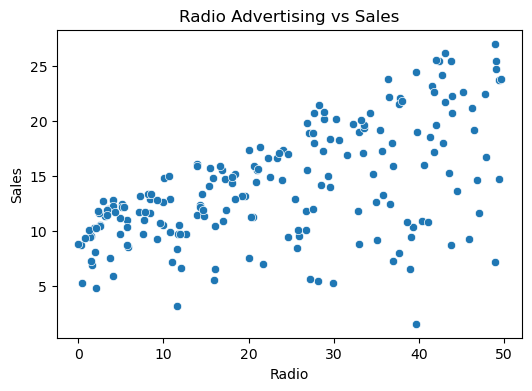

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Radio'], y=df['Sales'])
plt.title("Radio Advertising vs Sales")
plt.show()

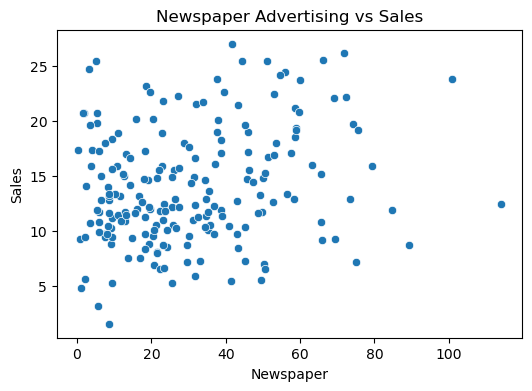

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Newspaper'], y=df['Sales'])
plt.title("Newspaper Advertising vs Sales")
plt.show()

In [33]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [36]:
print("Linear Regression Results")
print()

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results

MAE : 1.4607567168117606
MSE : 3.174097353976104
RMSE: 1.7815996615334502
R2 Score: 0.899438024100912


In [37]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [38]:
print("Random Forest Results")
print()

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results

MAE : 0.6192249999999989
MSE : 0.5864368749999992
RMSE: 0.765791665533126
R2 Score: 0.9814204656274288


In [39]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf)
    ],
    
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,MAE,MSE,R2 Score
0,Linear Regression,1.460757,3.174097,0.899438
1,Random Forest,0.619225,0.586437,0.981420


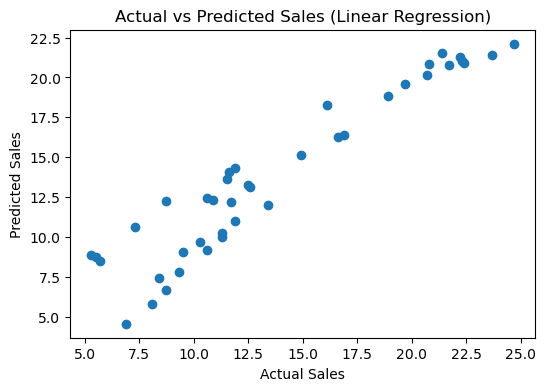

In [40]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales (Linear Regression)")

plt.show()

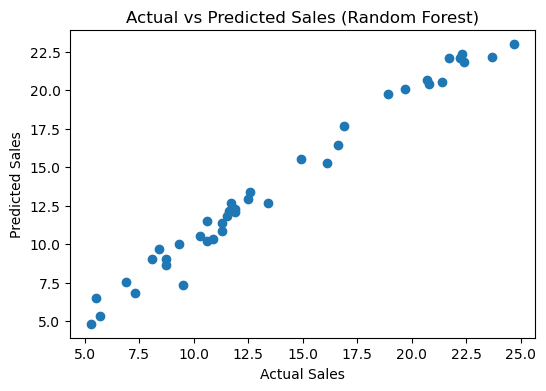

In [41]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales (Random Forest)")

plt.show()

# Conclusion

- TV advertising has the strongest relationship with sales.
- Machine learning models successfully predicted future sales.
- Random Forest performed better due to its ability to capture non-linear relationships.
- This project demonstrates how businesses can use machine learning for sales forecasting and marketing optimization.